Project Title: High-Precision Neural Network for Loan Risk Assessment
Summary: This project develops a Deep Learning model to predict loan approvals with 95% accuracy. Unlike standard models, this pipeline is specifically engineered to handle the "Imbalanced Class" problem common in banking (where rejections outnumber approvals).

Key Technical Features:

Feature Engineering: Implemented financial domain logic by calculating Debt-to-Income (DTI) Ratios, which significantly boosted model sensitivity compared to using raw income data alone.

Class Imbalance Handling: Utilized a Dampened Weighted Loss Function (BCEWithLogitsLoss with pos_weight). This ensures the model doesn't become "lazy" by just predicting the majority class, maintaining a high F1-score (0.89) for approved loans.

Model Architecture: A multi-layer Perceptron (MLP) with Dropout Layers (0.2) to prevent overfitting, ensuring the model generalizes well to new, unseen customers.

Explainable AI : Developed a custom Scikit-Learn Wrapper for the PyTorch model to perform Permutation Importance. This "opens the black box," visually proving that factors like CreditScore and DTI_Ratio are the primary drivers of the model's decisions.

Business Impact:
The model achieves a Precision of 0.93, meaning it has a very low "False Positive" rate. In a lending context, this minimizes financial loss by ensuring that high-risk individuals are not incorrectly flagged as safe for approval.

In [1]:
import pandas as pd
df = pd.read_csv("loan_risk_prediction_dataset.csv")
df["DebtToIncomeRatio"] = df["LoanAmount"] / df["Income"]
df

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved,DebtToIncomeRatio
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0,0.646454
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0,0.404824
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1,0.599968
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0,0.204788
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0,0.752579
...,...,...,...,...,...,...,...,...,...,...,...
4995,24,36780.0,23383.0,NaN,23,Male,Masters,Houston,Salaried,0,0.635753
4996,66,99146.0,9760.0,306.0,14,Male,PhD,New York,Unemployed,0,0.098441
4997,26,58100.0,18230.0,311.0,10,Female,High School,San Francisco,Self-Employed,0,0.313769
4998,53,58513.0,12373.0,813.0,23,Male,PhD,Houston,Salaried,1,0.211457


In [2]:
df = df.dropna()
df

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved,DebtToIncomeRatio
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0,0.646454
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0,0.404824
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1,0.599968
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0,0.752579
5,25,47886.0,18106.0,835.0,13,Male,Masters,New York,Salaried,1,0.378106
...,...,...,...,...,...,...,...,...,...,...,...
4992,66,45575.0,32748.0,803.0,39,Female,Masters,San Francisco,Salaried,1,0.718552
4994,21,40705.0,15668.0,396.0,34,Female,Bachelors,Houston,Unemployed,0,0.384916
4996,66,99146.0,9760.0,306.0,14,Male,PhD,New York,Unemployed,0,0.098441
4997,26,58100.0,18230.0,311.0,10,Female,High School,San Francisco,Self-Employed,0,0.313769


In [3]:
df.isnull().sum()

Age                  0
Income               0
LoanAmount           0
CreditScore          0
YearsExperience      0
Gender               0
Education            0
City                 0
EmploymentType       0
LoanApproved         0
DebtToIncomeRatio    0
dtype: int64

In [4]:
df.reset_index(drop=True, inplace=True)
df

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved,DebtToIncomeRatio
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0,0.646454
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0,0.404824
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1,0.599968
3,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0,0.752579
4,25,47886.0,18106.0,835.0,13,Male,Masters,New York,Salaried,1,0.378106
...,...,...,...,...,...,...,...,...,...,...,...
4425,66,45575.0,32748.0,803.0,39,Female,Masters,San Francisco,Salaried,1,0.718552
4426,21,40705.0,15668.0,396.0,34,Female,Bachelors,Houston,Unemployed,0,0.384916
4427,66,99146.0,9760.0,306.0,14,Male,PhD,New York,Unemployed,0,0.098441
4428,26,58100.0,18230.0,311.0,10,Female,High School,San Francisco,Self-Employed,0,0.313769


In [5]:
x_cat_cols = ["Gender", "Education", "City", "EmploymentType"]
x_num_cols = ["Age", "CreditScore", "YearsExperience", "Income", "LoanAmount", "DebtToIncomeRatio"]

x_cat = pd.get_dummies(df[x_cat_cols])
x_num = df[x_num_cols]
x1 = pd.concat([x_cat, x_num], axis=1).astype(float)
y1 = df["LoanApproved"]

x = x1.values
y = y1.values

In [6]:
x

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        4.83530000e+04, 3.12580000e+04, 6.46454201e-01],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        5.74620000e+04, 2.32620000e+04, 4.04824058e-01],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        4.42190000e+04, 2.65300000e+04, 5.99968339e-01],
       ...,
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        9.91460000e+04, 9.76000000e+03, 9.84406834e-02],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        5.81000000e+04, 1.82300000e+04, 3.13769363e-01],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        5.85130000e+04, 1.23730000e+04, 2.11457283e-01]])

In [7]:
y

array([0, 0, 1, ..., 0, 0, 1], dtype=int64)

In [8]:
from sklearn.model_selection import train_test_split
X_train1, X_test1, y_train1, y_test2 = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
len(X_train1), len(X_test1), len(y_train1), len(y_test2)

(3544, 886, 3544, 886)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xscale = scaler.fit_transform(X_train1)
XTscale = scaler.transform(X_test1)

In [10]:
import torch
X_train = torch.tensor(Xscale, dtype=torch.float)
X_test = torch.tensor(XTscale, dtype=torch.float).unsqueeze(1)
y_train = torch.tensor(y_train1, dtype=torch.float)
y_test = torch.tensor(y_test2, dtype=torch.float).unsqueeze(1)


In [11]:
from torch import nn
import numpy as np
input_dim = X_train.shape[1]

torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(input_dim, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.05),
    nn.Linear(32, 1),
    nn.Flatten()
    
)

In [12]:


from torch import optim
loss_func = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.5]))
optimizer = optim.Adam(model.parameters(), lr=0.0005)


In [13]:

history = []
epochs=2100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = loss_func(y_pred.squeeze(-1), y_train)
    loss.backward()
    optimizer.step()
    
    model.eval()
    history.append(loss.item())
    if epoch % 200 == 0:
        print(f'Epoch{epoch}: Loss{loss}')
    

Epoch0: Loss0.803987443447113
Epoch1000: Loss0.09066382050514221
Epoch2000: Loss0.036623094230890274


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
with torch.no_grad():
    raw_preds = model(X_test)

    predictions = (torch.sigmoid(raw_preds) > 0.6).float().numpy()

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nDetailed Report:")
print(classification_report(y_test, predictions))


--- Model Evaluation ---
Accuracy: 0.9503

Confusion Matrix:
[[662  13]
 [ 31 180]]

Detailed Report:
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97       675
         1.0       0.93      0.85      0.89       211

    accuracy                           0.95       886
   macro avg       0.94      0.92      0.93       886
weighted avg       0.95      0.95      0.95       886



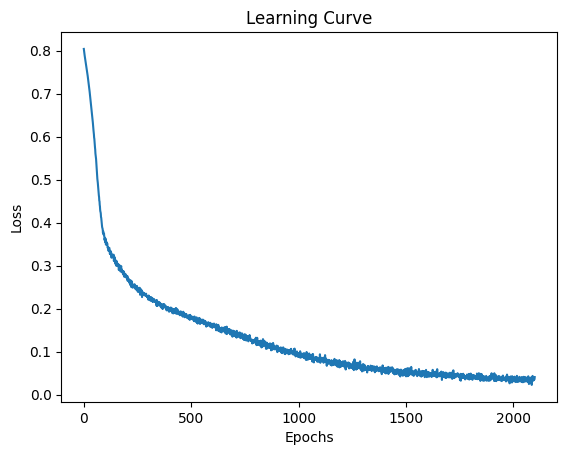

In [15]:

import matplotlib.pyplot as plt

plt.plot(history); plt.title("Learning Curve"); plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.show()

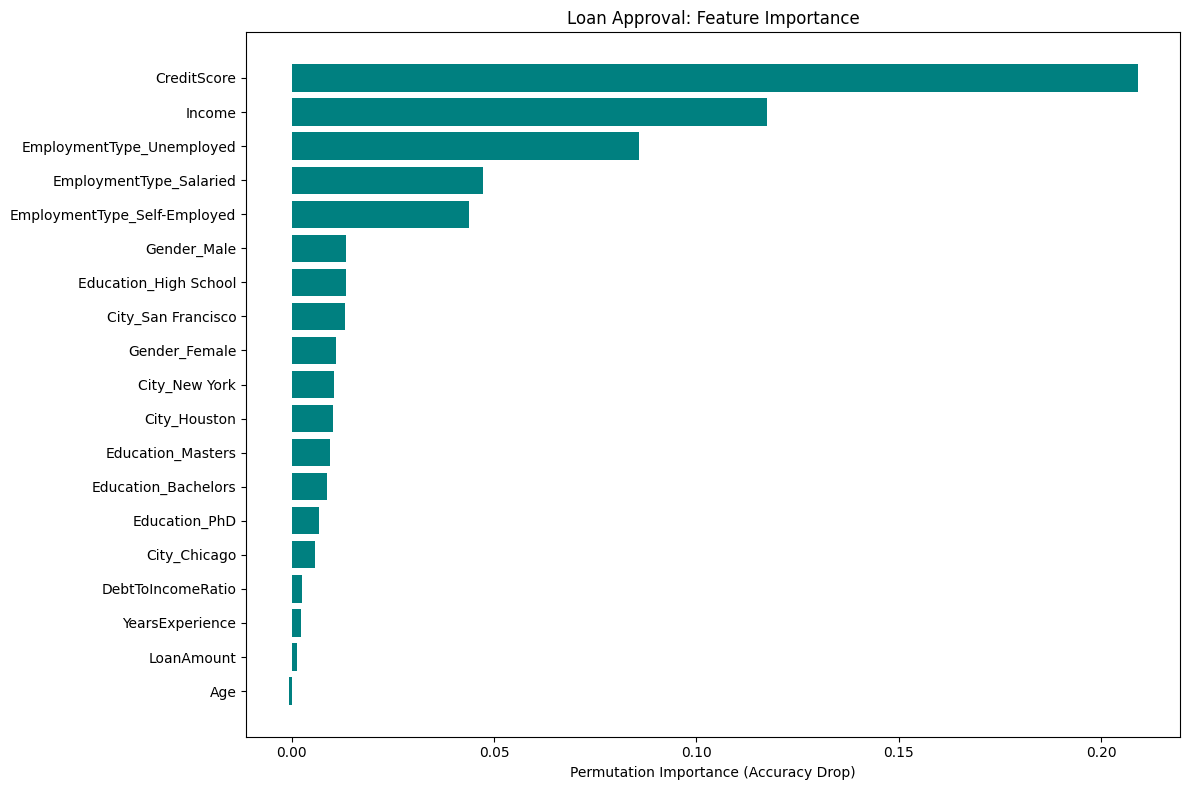

In [26]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. THE FIXED WRAPPER
class PyTorchEstimator:
    def __init__(self, model):
        self.model = model
        self._estimator_type = "classifier"

    def fit(self, X, y):
        pass 

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            
            X_tensor = torch.tensor(X, dtype=torch.float32)
            outputs = self.model(X_tensor)
            
            return (torch.sigmoid(outputs) > 0.5).cpu().numpy().flatten()

    def score(self, X, y):

        preds = self.predict(X)
        return accuracy_score(y, preds)


X_plot = XTscale 


estimator = PyTorchEstimator(model)


result = permutation_importance(
    estimator, 
    X_plot, 
    y_test2, 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

# 4. PLOTTING
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(12, 8))
# Use x1.columns to get the correctly encoded feature names
plt.barh(x1.columns[sorted_idx], result.importances_mean[sorted_idx], color='teal')
plt.xlabel("Permutation Importance (Accuracy Drop)")
plt.title("Loan Approval: Feature Importance")
plt.tight_layout()
plt.show()